In [1]:
import pandas as pd
import os
from pathlib import Path

def standardize_columns(df):
    """
    Renames columns based on keywords to match the requested format:
    acc_mean, acc_std, wacc_mean, wacc_std, tau_mean, tau_std
    """
    new_cols = {}
    for col in df.columns:
        c_low = col.lower()
        
        # Weighted Accuracy (Check this before Accuracy to avoid false positives)
        if 'weighted' in c_low or 'wacc' in c_low:
            new_cols[col] = 'wacc_std' if 'std' in c_low else 'wacc_mean'
        
        # Accuracy
        elif 'accuracy' in c_low or 'acc' in c_low:
            new_cols[col] = 'acc_std' if 'std' in c_low else 'acc_mean'
            
        # Kendall's Tau
        elif 'tau' in c_low or 'kendall' in c_low:
            new_cols[col] = 'tau_std' if 'std' in c_low else 'tau_mean'
            
    return df.rename(columns=new_cols)

# Path to the results directory
results_dir = Path("../results")
records = []

if results_dir.exists():
    for spammer_folder in results_dir.iterdir():
        if spammer_folder.is_dir():
            spammer_type = spammer_folder.name
            
            for csv_file in spammer_folder.glob("*.csv"):
                method_name = csv_file.stem 
                
                try:
                    df_temp = pd.read_csv(csv_file)
                    
                    # 1. Rename columns based on rules
                    df_temp = standardize_columns(df_temp)
                    
                    # 2. Add identification columns
                    df_temp['SpammerType'] = spammer_type
                    df_temp['method'] = method_name
                    
                    records.append(df_temp)
                except Exception as e:
                    print(f"Error reading {csv_file}: {e}")

if records:
    # 3. Concatenate and Sort
    data = pd.concat(records, ignore_index=True)
    
    # Reorder columns: ID info first, then metrics
    meta_cols = ['SpammerType', 'method', 'percent']
    metric_cols = ['acc_mean', 'acc_std', 'wacc_mean', 'wacc_std', 'tau_mean', 'tau_std']
    
    # Final filter to ensure we only include columns that actually exist
    final_cols = [c for c in meta_cols if c in data.columns] + \
                 [c for c in metric_cols if c in data.columns]
    
    data = data[final_cols]
    data = data.sort_values(["SpammerType", "percent", "method"]).reset_index(drop=True)

    print(f"Collected {len(data)} metric rows.")
    print("DataFrame head:\n", data.head())
    
    # Save the consolidated results
    data.to_csv("consolidated_results.csv", index=False)
else:
    print("No data found. Please check if '../results' exists and contains subfolders with CSVs.")

Collected 175 metric rows.
DataFrame head:
   SpammerType    method  percent  acc_mean   acc_std  wacc_mean  wacc_std  \
0        anti    GradEM       10  0.695882  0.001073   0.755926  0.000771   
1        anti      barp       10  0.685636  0.000507   0.750004  0.000501   
2        anti        bt       10  0.677829  0.000442   0.740127  0.000598   
3        anti   crowdbt       10  0.699733  0.001078   0.759995  0.001040   
4        anti  factorbt       10  0.695313  0.001072   0.743136  0.001302   

   tau_mean   tau_std  
0  0.369829  0.002025  
1  0.350504  0.000958  
2  0.335841  0.000842  
3  0.377100  0.002034  
4  0.368756  0.002021  


In [2]:
data

,SpammerType,method,percent,acc_mean,acc_std,wacc_mean,wacc_std,tau_mean,tau_std
0,anti,GradEM,10,0.695882,0.001073,0.755926,0.000771,0.369829,0.002025
1,anti,barp,10,0.685636,0.000507,0.750004,0.000501,0.350504,0.000958
2,anti,bt,10,0.677829,0.000442,0.740127,0.000598,0.335841,0.000842
3,anti,crowdbt,10,0.699733,0.001078,0.759995,0.001040,0.377100,0.002034
4,anti,factorbt,10,0.695313,0.001072,0.743136,0.001302,0.368756,0.002021
...,...,...,...,...,...,...,...,...,...
170,right,bt,80,0.648363,0.000416,0.697416,0.000575,0.280201,0.000790
171,right,crowdbt,80,0.691709,0.030009,0.750503,0.037860,0.361950,0.056658
172,right,factorbt,80,0.650312,0.001406,0.698018,0.002083,0.283793,0.002655
173,right,pgem,80,0.676370,0.033650,0.732612,0.045585,0.332990,0.063533


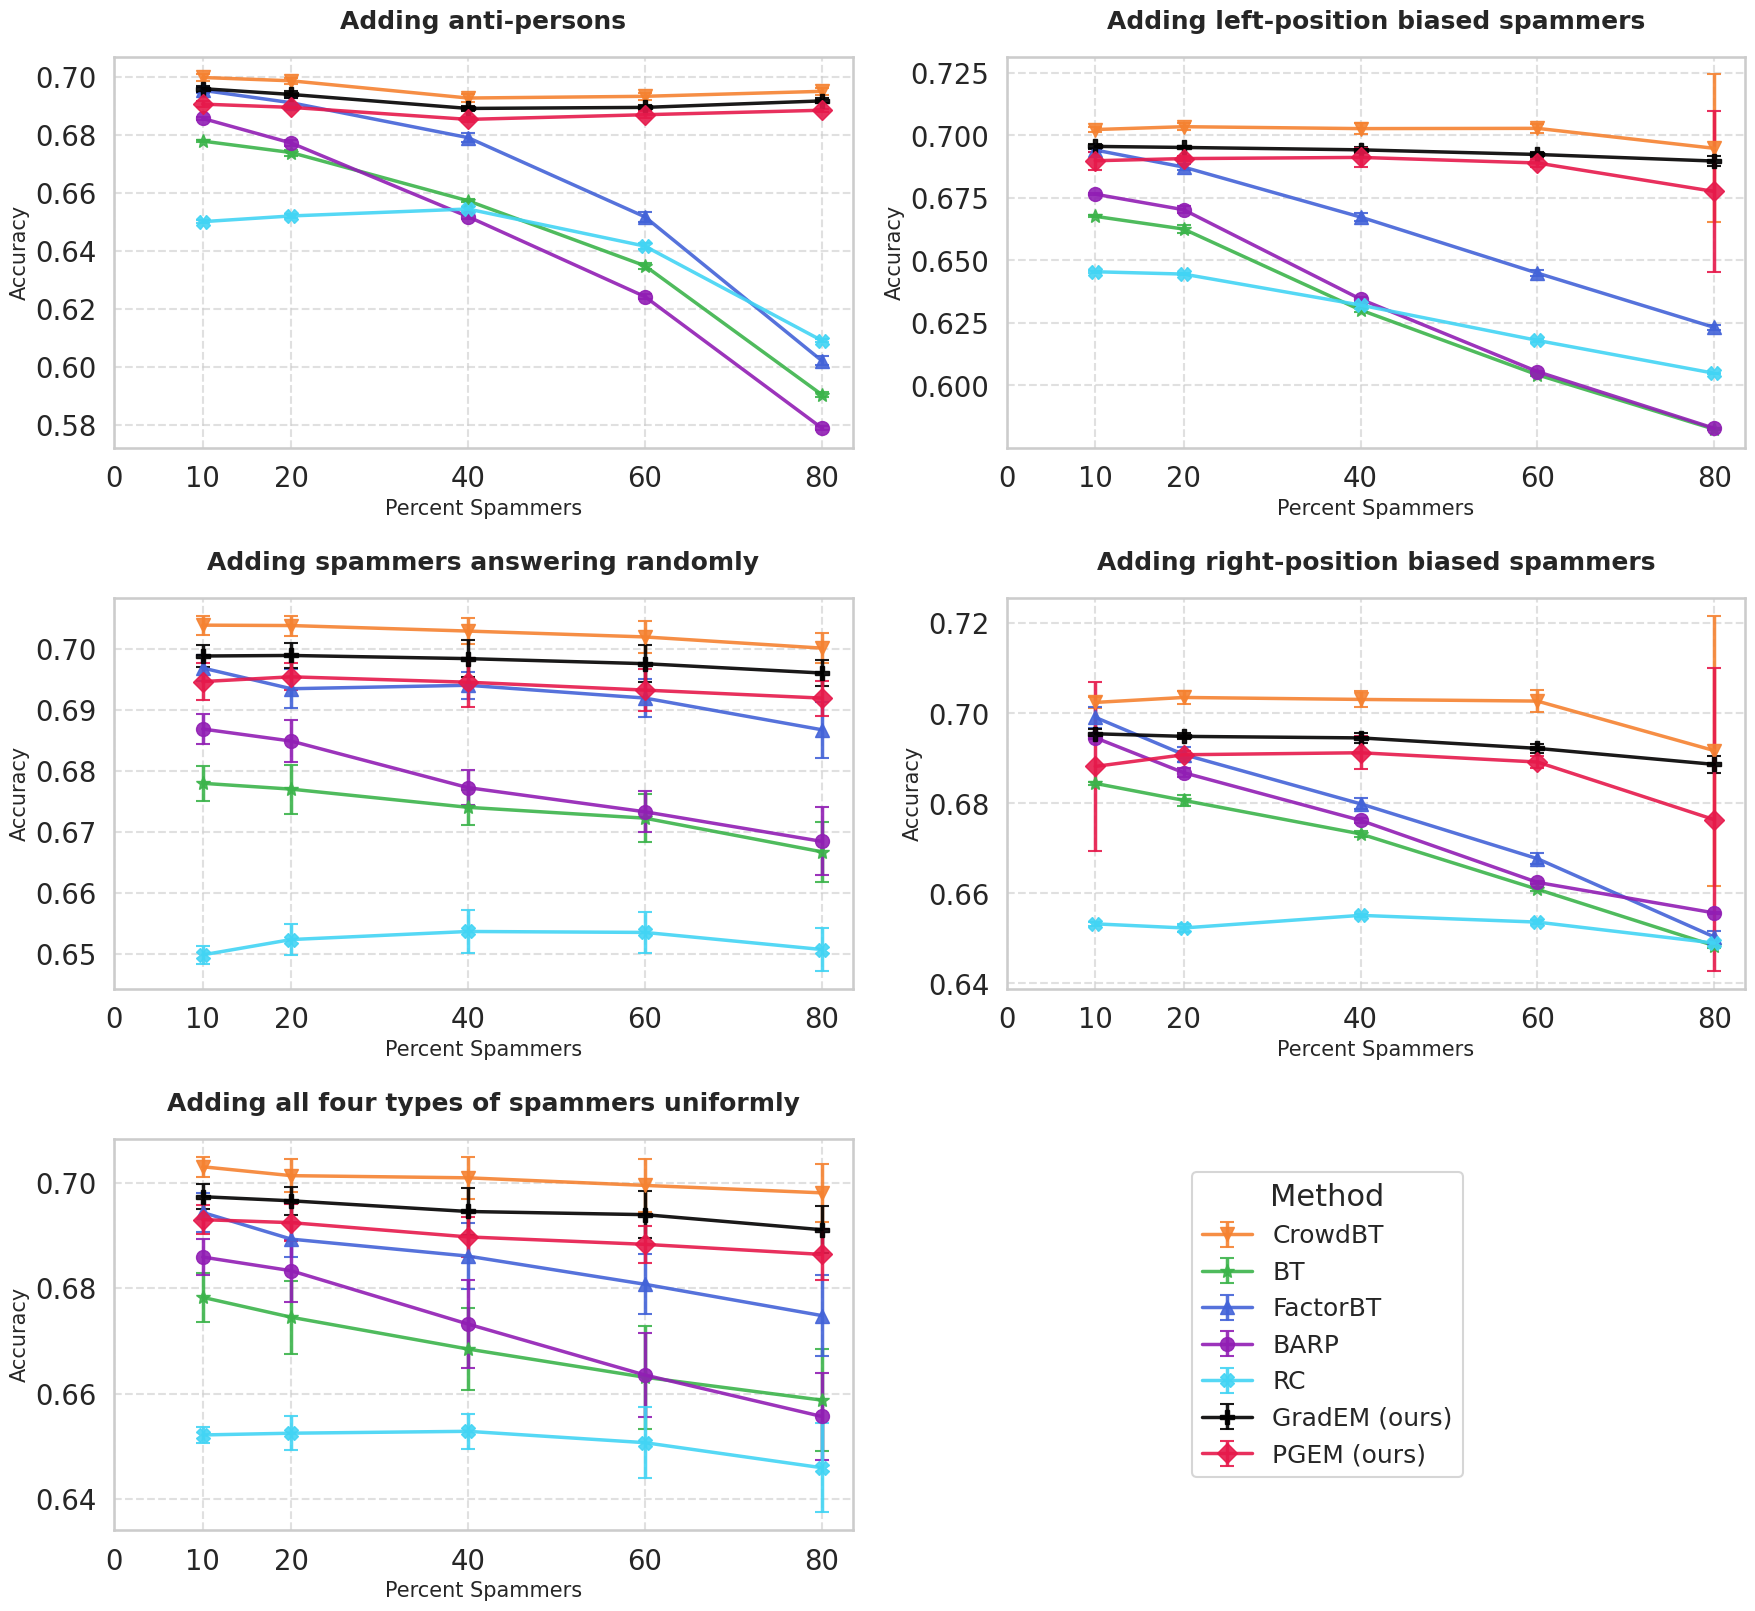

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Set the style
sns.set_theme(style="whitegrid", font_scale=1.2, context="talk")

# 2. Setup Variables and Reorder Spammer Types
all_types = list(data["SpammerType"].unique())
if "equal" in all_types:
    all_types.remove("equal")
    spammer_types = all_types + ["equal"]
else:
    spammer_types = all_types

# Descriptive Title Mapping
title_map = {
    "equal": "Adding all four types of spammers uniformly",
    "anti": "Adding anti-persons",
    "left": "Adding left-position biased spammers",
    "right": "Adding right-position biased spammers",
    "random": "Adding spammers answering randomly"
}

# Define parameters matching your requirements
method_order = ['CrowdBT', 'BT', 'FactorBT', 'BARP', 'RC', 'GradEM', 'PGEM']
colors = ["#F58231", "#3CB44B", "#4363D8", "#911EB4", "#42D4F4", "#010000", "#E6194B"]
markers = ['v', '*', '^', 'o', 'X', 'P', 'D']

# Create mapping dictionaries for the loop
color_map = dict(zip(method_order, colors))
marker_map = dict(zip(method_order, markers))

# 3. Create the Grid Plot
n_types = len(spammer_types)
n_cols = 2
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), squeeze=False)
axes = axes.flatten()

for i, stype in enumerate(spammer_types):
    ax = axes[i]
    subset = data[data["SpammerType"] == stype]
    
    # Use case-insensitive matching for methods present in the data
    available_methods_lower = subset["method"].str.lower().unique()

    for method in method_order:
        if method.lower() not in available_methods_lower:
            continue
            
        # Extract data for the method
        mdf = subset[subset["method"].str.lower() == method.lower()].sort_values("percent")
        color = color_map.get(method)
        marker = marker_map.get(method)
        
        # Plotting with error bars (since all have std dev)
        # Using .get() for std to avoid errors if a specific row is missing it
        ax.errorbar(
            mdf["percent"], mdf["acc_mean"], 
            yerr=mdf.get("acc_std", 0),
            label=method, 
            marker=marker, 
            markersize=10, 
            linewidth=2.5, 
            capsize=5, 
            capthick=1.5,
            color=color, 
            alpha=0.9
        )

    # Customize the subplot title
    display_title = title_map.get(stype, f"Effect of {stype.capitalize()} Spammers")
    ax.set_title(display_title, fontsize=18, fontweight='bold', pad=20)
    
    ax.set_xlabel("Percent Spammers", fontsize=15)
    ax.set_ylabel("Accuracy", fontsize=15)
    ax.set_xticks([0, 10, 20, 40, 60, 80])
    ax.grid(True, linestyle="--", alpha=0.6)

# 4. Global Legend Logic
# Extract handles/labels from the first axis that actually plotted something
handles, labels = axes[0].get_legend_handles_labels()

# Sort handles/labels to match your specified method_order exactly
label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[m] for m in method_order if m in label_to_handle]
ordered_labels = [m for m in method_order if m in label_to_handle]

updated_labels = []
for method in ordered_labels:
    if "EM" in method:
        method = method + " " + "(ours)"
    updated_labels.append(method)
# 1. Update legend position: loc='lower center', bbox_to_anchor=(0.5, -0.05)
fig.legend(ordered_handles, updated_labels, 
           loc='lower center', 
           bbox_to_anchor=(0.75, 0.16), # Adjust this to move it up/down
           ncol=1, 
           title="Method", 
           fontsize=18, 
           title_fontsize=22, 
           frameon=True)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 2. Update tight_layout: rect=[0, 0.12, 1, 1] 
# The 0.12 (bottom) creates room for the legend at the bottom
plt.tight_layout(rect=[0, 0.08, 1, 1])
# Save with high quality settings
plt.savefig(
    "spammer_analysis_passage.pdf", 
    format="pdf", 
    dpi=300,                # High resolution
    bbox_inches="tight",    # Removes extra whitespace around the plot
    transparent=True        # Useful if placing on a non-white background
)
plt.show()